# Predict the Taxi Cancellation

In late 2013, the taxi company Yourcabs.com in Bangalore, India was facing a
problem with the drivers using their platform—not all drivers were showing up
for their scheduled calls. Drivers would cancel their acceptance of a call, and,
if the cancellation did not occur with adequate notice, the customer would be
delayed or even left high and dry.
Bangalore is a key tech center in India, and technology was transforming
the taxi industry. Yourcabs.com featured an online booking system (though
customers could phone in as well), and presented itself as a taxi booking portal.
The Uber ride sharing service started its Bangalore operations in mid-2014.
Yourcabs.com had collected data on its bookings from 2011 to 2013, and
posted a contest on Kaggle, in coordination with the Indian School of Business,
to see what it could learn about the problem of cab cancellations.
The data presented for this case are a randomly selected subset of the original
data, with 10,000 rows, one row for each booking. There are 17 input variables,
including user (customer) ID, vehicle model, whether the booking was made
online or via a mobile app, type of travel, type of booking package, geographic
information, and the date and time of the scheduled trip. The target variable
of interest is the binary indicator of whether a ride was canceled. The overall
cancellation rate is between 7% and 8%.
Assignment

1. How can a predictive model based on these data be used by Your-
cabs.com?

2. How can a profiling model (identifying predictors that distinguish can-
celed/uncanceled trips) be used by Yourcabs.com?

3. Explore, prepare, and transform the data to facilitate predictive modeling.
Here are some hints:
• In exploratory modeling, it is useful to move fairly soon to at least an
initial model without solving all data preparation issues. One example
is the GPS information—other geographic information is available so
you could defer the challenge of how to interpret/use the GPS infor-
mation.

• How will you deal with missing data, such as cases where NULL is
indicated?
• Think about what useful information might be held within the date
and time fields (the booking timestamp and the trip timestamp). The

data file contains a worksheet with some hints on how to extract fea-
tures from the date/time field.

• Think also about the categorical variables, and how to deal with them.
Should we turn them all into dummies? Use only some?
4. Fit several predictive models of your choice. Do they provide information
on how the predictor variables relate to cancellations?
5. Report the predictive performance of your model in terms of error rates
(the confusion matrix). How well does the model perform? Can the
model be used in practice?
6. Examine the predictive performance of your model in terms of ranking
(lift). How well does the model perform? Can the model be used in
practice?

### Importing Modules and Data

In [1]:
# install the book's module to load the datasets
# !pip install dmba

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import dmba
df = dmba.load_data('Taxi-cancellation-case.csv')
print(df.shape)

no display found. Using non-interactive Agg backend
(10000, 19)


In [4]:
df.head()

,row#,user_id,vehicle_model_id,package_id,travel_type_id,from_area_id,to_area_id,from_city_id,to_city_id,from_date,to_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation
0,1,17712,12,NaN,2,1021.0,1323.0,NaN,NaN,1/1/13 22:33,NaN,0,0,1/1/13 8:01,13.028530,77.54625,12.869805,77.653211,0
1,2,17037,12,NaN,2,455.0,1330.0,NaN,NaN,1/1/13 12:43,NaN,0,0,1/1/13 9:59,12.999874,77.67812,12.953434,77.706510,0
2,3,761,12,NaN,2,814.0,393.0,NaN,NaN,1/2/13 0:28,1/3/13 0:00,1,0,1/1/13 12:14,12.908993,77.68890,13.199560,77.706880,0
3,4,868,12,NaN,2,297.0,212.0,NaN,NaN,1/1/13 13:12,NaN,0,0,1/1/13 12:42,12.997890,77.61488,12.994740,77.607970,0
4,5,21716,28,NaN,2,1237.0,330.0,NaN,NaN,1/1/13 16:33,NaN,0,0,1/1/13 15:07,12.926450,77.61206,12.858833,77.589127,0


In [7]:
df['Car_Cancellation'].value_counts()

Car_Cancellation
0    9257
1     743
Name: count, dtype: int64

In [12]:
df.isna().mean().multiply(100)

row#                    0.00
user_id                 0.00
vehicle_model_id        0.00
package_id             82.48
travel_type_id          0.00
from_area_id            0.15
to_area_id             20.91
from_city_id           62.94
to_city_id             96.61
from_date               0.00
to_date                41.78
online_booking          0.00
mobile_site_booking     0.00
booking_created         0.00
from_lat                0.15
from_long               0.15
to_lat                 20.91
to_long                20.91
Car_Cancellation        0.00
dtype: float64

In [ ]:
df.corr(numeric_only= True)

In [8]:
df.agg(['nunique'])
df.nunique()

row#                   10000
user_id                 7044
vehicle_model_id          20
package_id                 7
travel_type_id             3
from_area_id             522
to_area_id               479
from_city_id               2
to_city_id                67
from_date               7976
to_date                 5332
online_booking             2
mobile_site_booking        2
booking_created         9611
from_lat                 422
from_long                419
to_lat                   390
to_long                  387
Car_Cancellation           2
dtype: int64

In [20]:
df["Car_Cancellation"].mean()

np.float64(0.0743)

In [21]:
df.groupby('online_booking')["Car_Cancellation"].mean()


online_booking
0    0.045771
1    0.126521
Name: Car_Cancellation, dtype: float64

In [20]:
df.groupby('mobile_site_booking')["Car_Cancellation"].mean()


,Car_Cancellation
mobile_site_booking,
0,0.071011
1,0.148585


In [6]:
df.isna().sum()

,0
row#,0
user_id,0
vehicle_model_id,0
package_id,8248
travel_type_id,0
from_area_id,15
to_area_id,2091
from_city_id,6294
to_city_id,9661
from_date,0


In [8]:
df.isna().mean().multiply(100)

,0
row#,0.00
user_id,0.00
vehicle_model_id,0.00
package_id,82.48
travel_type_id,0.00
from_area_id,0.15
to_area_id,20.91
from_city_id,62.94
to_city_id,96.61
from_date,0.00


In [12]:
df.corr(numeric_only= True)

,row#,user_id,vehicle_model_id,package_id,travel_type_id,from_area_id,to_area_id,from_city_id,to_city_id,online_booking,mobile_site_booking,from_lat,from_long,to_lat,to_long,Car_Cancellation
row#,1.000000,0.524794,0.060694,0.360748,0.005886,0.019143,0.018084,0.173360,0.077183,0.081803,0.076658,0.043401,0.030137,0.018827,0.014266,0.113186
user_id,0.524794,1.000000,0.057939,0.243260,-0.045869,0.019908,0.018186,0.060815,0.061069,0.094136,0.053821,0.050181,0.013944,0.044575,0.016528,0.097974
vehicle_model_id,0.060694,0.057939,1.000000,0.062042,-0.017523,-0.025625,-0.024712,-0.049923,0.067520,0.015227,-0.010577,0.058247,0.045493,0.047053,0.052966,-0.036783
package_id,0.360748,0.243260,0.062042,1.000000,NaN,0.002648,NaN,NaN,NaN,-0.027910,-0.022040,-0.022138,0.042027,NaN,NaN,0.092864
travel_type_id,0.005886,-0.045869,-0.017523,NaN,1.000000,0.028408,NaN,0.257683,NaN,-0.072741,-0.007887,-0.090622,-0.025471,NaN,NaN,-0.021030
from_area_id,0.019143,0.019908,-0.025625,0.002648,0.028408,1.000000,0.004289,-0.004090,0.059837,0.023917,-0.010125,-0.103469,-0.110703,0.006795,0.005622,0.016876
to_area_id,0.018084,0.018186,-0.024712,NaN,NaN,0.004289,1.000000,NaN,NaN,-0.011734,-0.001378,0.040698,0.026354,-0.253912,-0.258660,0.072605
from_city_id,0.173360,0.060815,-0.049923,NaN,0.257683,-0.004090,NaN,1.000000,-0.019310,-0.100089,0.020730,-0.032703,-0.032166,NaN,NaN,0.028999
to_city_id,0.077183,0.061069,0.067520,NaN,NaN,0.059837,NaN,-0.019310,1.000000,-0.047344,-0.014543,-0.018335,0.090887,NaN,NaN,0.062205
online_booking,0.081803,0.094136,0.015227,-0.027910,-0.072741,0.023917,-0.011734,-0.100089,-0.047344,1.000000,-0.155529,0.044028,0.068453,0.065458,0.020408,0.147177


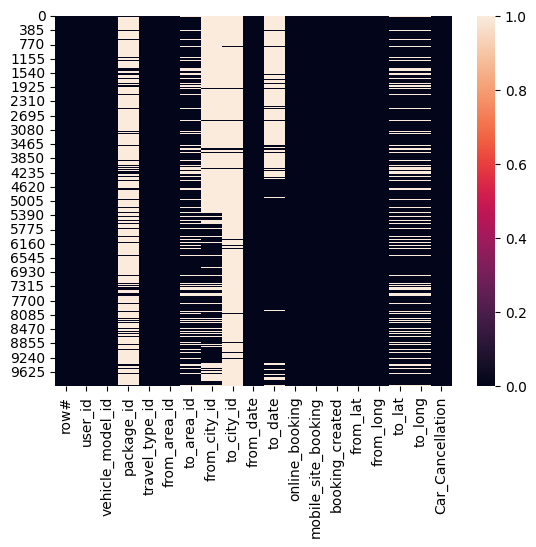

In [11]:
sns.heatmap(df.isna());

## How would you approach

**Data cleaning**

*

**Data Prep / Feature Engineering**
* Latitude and lonitude can be used to impute the missing city value details
* Journey distance calculation
* can impute the to-date


**EDA**
* How does the cancellation relate to channel


**Model building**